In [ ]:
!pip install kagglehub

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)

In [ ]:

n_customers = 500
n_features = 10


mean = np.random.uniform(50, 200, n_features)
cov = np.random.uniform(0.5, 2.0, (n_features, n_features))
cov = cov @ cov.T
data = np.random.multivariate_normal(mean, cov, n_customers)
data = np.abs(data)

categories = [f'Category_{i+1}' for i in range(n_features)]
df = pd.DataFrame(data, columns=categories)

print("Data shape:", df.shape)
df.head()

Data shape: (500, 10)


,Category_1,Category_2,Category_3,Category_4,Category_5,Category_6,Category_7,Category_8,Category_9,Category_10
0,107.922951,195.131883,164.395650,142.472996,77.585350,76.273297,61.973934,181.589843,143.453475,159.748498
1,105.739540,193.493025,163.133294,142.198370,75.325718,73.495350,62.415918,180.744526,141.167702,156.989781
2,107.327518,191.126519,160.225713,140.118342,76.163915,74.645347,59.410934,178.329407,142.134451,156.501941
3,106.828870,194.200344,159.402245,138.840256,75.088099,74.797233,59.633196,181.708875,141.139493,155.632526
4,107.410840,188.942586,154.786852,137.538322,70.294048,73.490730,54.069306,179.915725,137.828476,154.129168


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

Algorithm 1 : PCA

Explained variance ratio: [0.89480112 0.04306585]
Total explained variance: 0.9378669753846666


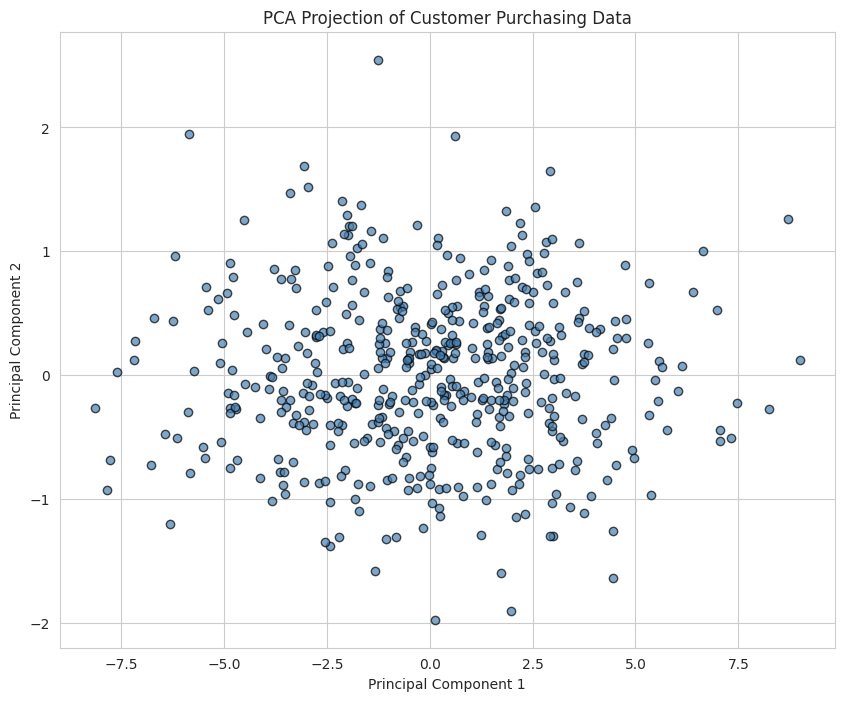

In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))


plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, c='steelblue', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Customer Purchasing Data')
plt.grid(True)
plt.show()

Algorithm 2 : t-SNE


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


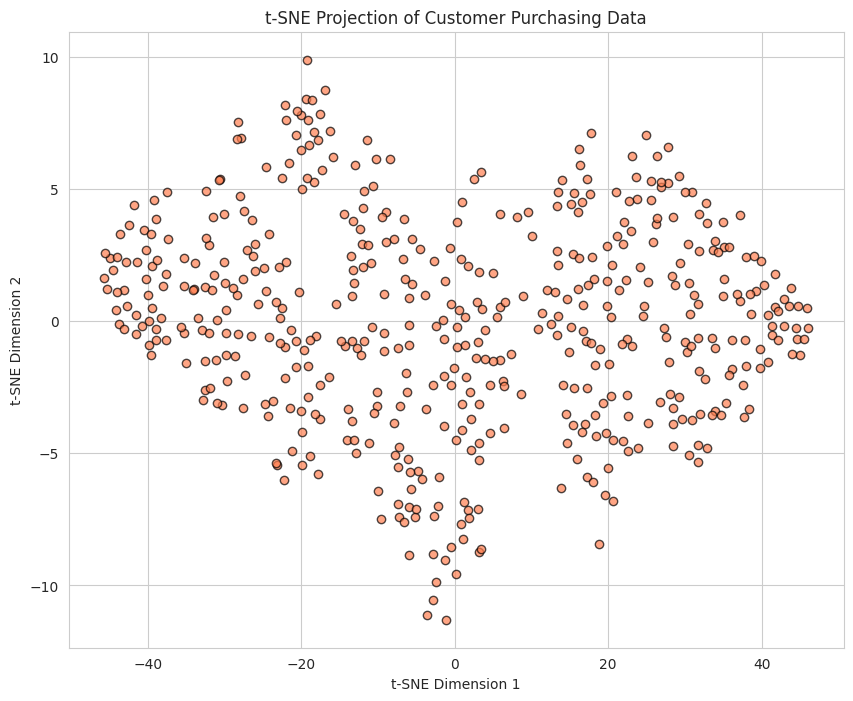

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7, c='coral', edgecolor='k')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.title('t‑SNE Projection of Customer Purchasing Data')
plt.grid(True)
plt.show()

Algorithm 3: K‑Means Clustering + PCA Visualization

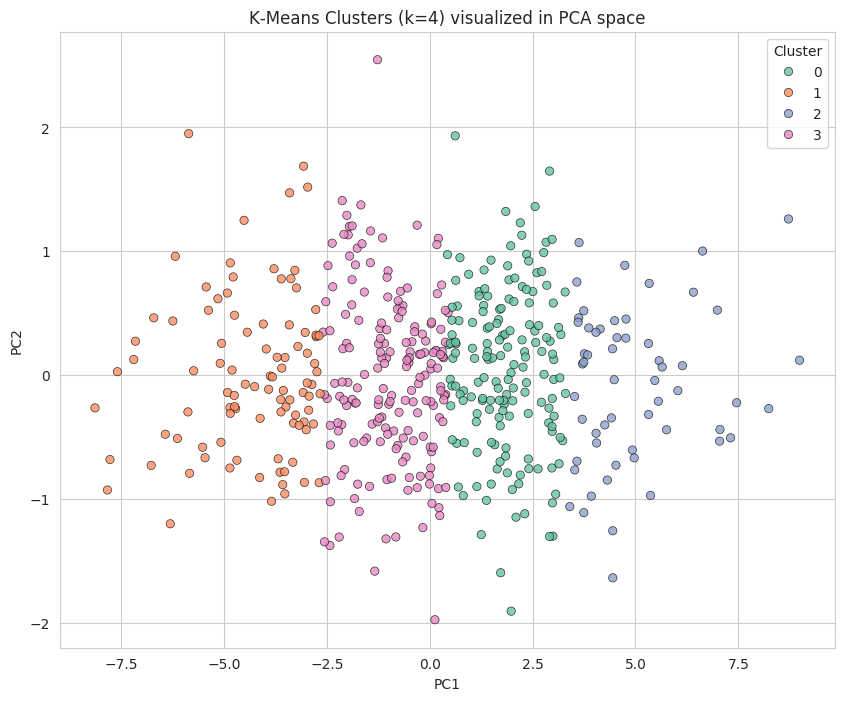

In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', alpha=0.8, edgecolor='k')
plt.title('K‑Means Clusters (k=4) visualized in PCA space')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

In [ ]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=df.columns)
centroid_df.index = [f'Cluster {i}' for i in range(k)]
print("Cluster centroids (average purchase amounts):")
print(centroid_df)

Cluster centroids (average purchase amounts):
           Category_1  Category_2  Category_3  Category_4  Category_5  \
Cluster 0  108.407431  194.697388  162.075521  141.994775   76.052709   
Cluster 1  101.195207  187.303456  153.932700  134.553485   66.715045   
Cluster 2  111.666199  198.569220  166.873280  145.559642   80.816101   
Cluster 3  104.969048  191.541867  158.483640  138.457007   71.932085   

           Category_6  Category_7  Category_8  Category_9  Category_10  
Cluster 0   75.634501   61.027591  182.477790  142.553590   158.437042  
Cluster 1   67.758807   53.191147  174.129955  134.681706   151.101042  
Cluster 2   79.689090   65.188109  186.561701  146.400919   162.132753  
Cluster 3   72.160341   57.509538  178.767371  138.873360   155.012689  
